# Kuantifikasi Fluoresensi Mitokondria dengan Computer Vision

Notebook ini memvalidasi ide tugas besar IF3211 untuk topik respirasi sel dan produksi energi. Framing akhir dibatasi pada kuantifikasi citra fluoresensi mitokondria sebagai indikator tidak langsung keadaan/sinyal mitokondria, bukan pengukuran ATP absolut.

## 1. Validasi Dataset

Dataset yang dipilih adalah **BBBC053: Murine Cath.a differentiated cells - Mitochondria** dari Broad Bioimage Benchmark Collection. Dataset ini relevan karena menampilkan mitochondria yang divisualisasi memakai TOM20 antibody dan AlexaFluor 568. Implementasi memakai archive resmi `FCCP-20220127T153841Z-001.zip` dan mengekstrak **58 citra TIFF 16-bit full-resolution**: 29 DMSO dan 29 FCCP.

Sumber: https://bbbc.broadinstitute.org/BBBC053

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name != "KDS":
    ROOT = ROOT.parent if (ROOT.parent / "Tubes").exists() else ROOT
TUBES = ROOT / "Tubes"
sys.path.insert(0, str(TUBES / "src"))

from bioenergetics import (
    DATASET_CONFIG,
    analyze_image,
    analyze_records,
    compare_conditions,
    dataset_validation_summary,
    mask_to_image,
    overlay_mask,
    preprocessed_to_image,
    read_sample_manifest,
)

DATA_DIR = TUBES / "data"
OUTPUT_DIR = TUBES / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

In [2]:
validation = dataset_validation_summary()
validation

,criterion,evidence,status
0,Sumber publik,https://bbbc.broadinstitute.org/BBBC053,valid
1,Pemilihan sumber,BBBC dipilih karena langsung menyediakan datas...,valid
2,Relevansi biologis,Mitochondria visualized with TOM20 antibody an...,valid
3,Format data,"Dataset penuh: 2048 x 2048 pixel, 16-bit TIFF;...",valid with subset
4,Kelayakan komputasi,58 TIFF full-resolution diproses lokal; metode...,valid
5,Batasan klaim,Intensitas fluoresensi diperlakukan sebagai in...,valid


## 2. Keputusan Metode

BBBC053 memiliki label biologis tingkat kondisi, tetapi tidak menyediakan bounding box atau segmentation mask lokal untuk training object detection. Karena itu pendekatan yang paling realistis adalah classical computer vision: background subtraction, Gaussian denoising, threshold Otsu, connected components, dan ekstraksi fitur intensitas. Metode ini berjalan tanpa GPU dan cukup transparan untuk laporan pendek.

In [3]:
records = read_sample_manifest(DATA_DIR)
summary_rows = []
for condition in sorted({record.condition for record in records}):
    group = [record for record in records if record.condition == condition]
    summary_rows.append({
        "condition": condition,
        "n_images": len(group),
        "example_file": group[0].path.name,
        "image_size_bytes": group[0].path.stat().st_size,
    })
manifest_summary = pd.DataFrame(summary_rows)
manifest_summary

,condition,n_images,example_file,image_size_bytes
0,DMSO,29,MAX_DMSO_ (1) - Deconvolved.tif,8390388
1,FCCP,29,MAX_FCCP_ (1) - Deconvolved.tif,8390388


## 3. Analisis Kuantitatif

Fitur minimum yang dihitung adalah mean intensity, total fluorescence, area, integrated density, jumlah objek/komponen, dan metrik kualitas sederhana berupa signal-to-background serta quality flag. Seluruh 58 citra TIFF dianalisis, bukan hanya preview.

In [4]:
metrics = analyze_records(records)
metrics.to_csv(OUTPUT_DIR / "notebook_image_metrics.csv", index=False)
metrics.round(4).head()

,dataset,image_id,condition,filename,source_url,mean_intensity,total_fluorescence,area_pixels,integrated_density,object_count,coverage_fraction,threshold,background_mean,background_std,signal_to_background,quality_flag
0,BBBC053,dmso_1,DMSO,MAX_DMSO_ (1) - Deconvolved.tif,https://bbbc.broadinstitute.org/BBBC053,0.9481,794853.3125,838329,794853.3291,218,0.1999,0.5176,0.1070,0.1046,8.0407,usable
1,BBBC053,dmso_11,DMSO,MAX_DMSO_ (11) - Deconvolved.tif,https://bbbc.broadinstitute.org/BBBC053,0.9396,954048.5000,1015404,954048.4721,288,0.2421,0.5137,0.1090,0.1072,7.7474,usable
2,BBBC053,dmso_12,DMSO,MAX_DMSO_ (12) - Deconvolved.tif,https://bbbc.broadinstitute.org/BBBC053,0.9306,696425.4375,748360,696425.4571,411,0.1784,0.5020,0.0970,0.1058,7.8809,usable
3,BBBC053,dmso_13,DMSO,MAX_DMSO_ (13) - Deconvolved.tif,https://bbbc.broadinstitute.org/BBBC053,0.9425,694599.5000,736969,694599.5166,332,0.1757,0.4980,0.0910,0.1006,8.4664,usable
4,BBBC053,dmso_14,DMSO,MAX_DMSO_ (14) - Deconvolved.tif,https://bbbc.broadinstitute.org/BBBC053,0.9410,665188.0625,706930,665188.0422,475,0.1685,0.5137,0.1027,0.1061,7.8971,usable


In [5]:
condition_summary = compare_conditions(metrics)
condition_summary.to_csv(OUTPUT_DIR / "notebook_condition_summary.csv", index=False)
condition_summary.round(4)

,condition,mean_intensity,total_fluorescence,area_pixels,integrated_density,object_count,coverage_fraction,signal_to_background
0,DMSO,0.9333,796849.7554,853055.5517,796849.7546,416.9655,0.2034,8.0808
1,FCCP,0.9106,906938.6530,995016.8966,906938.6464,1224.3103,0.2372,6.3124


PosixPath('/Users/macbook/Documents/coding/KDS/Tubes/outputs/figures/notebook_metric_distributions.png')

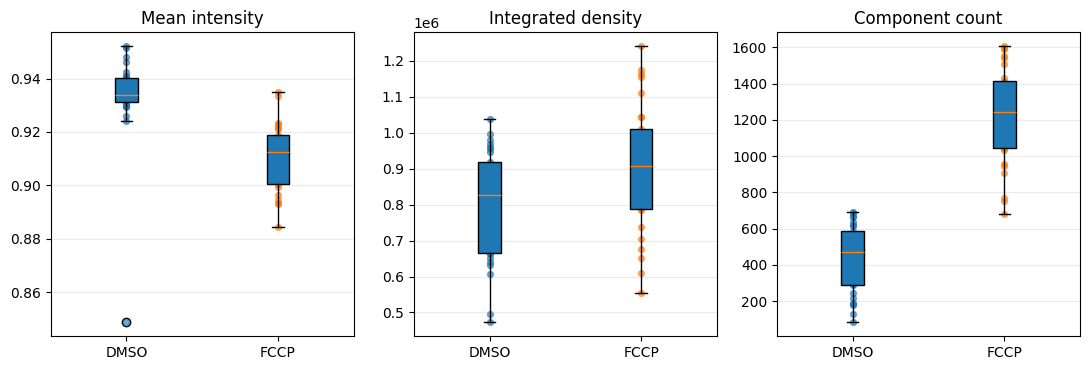

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
plot_specs = [
    ("mean_intensity", "Mean intensity"),
    ("integrated_density", "Integrated density"),
    ("object_count", "Component count"),
]
for ax, (column, title) in zip(axes, plot_specs):
    groups = [group[column].to_numpy() for _, group in metrics.groupby("condition", sort=True)]
    labels = [condition for condition, _ in metrics.groupby("condition", sort=True)]
    ax.boxplot(groups, tick_labels=labels, patch_artist=True)
    for idx, values in enumerate(groups, start=1):
        ax.scatter([idx] * len(values), values, s=18, alpha=0.6)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
metric_plot_path = FIGURE_DIR / "notebook_metric_distributions.png"
fig.savefig(metric_plot_path, dpi=180)
metric_plot_path

## 4. Visualisasi Mask dan Overlay

Agar notebook tetap ringan, visualisasi ditampilkan untuk dua contoh per kondisi. Analisis numeriknya tetap memakai seluruh 58 citra.

PosixPath('/Users/macbook/Documents/coding/KDS/Tubes/outputs/figures/notebook_mask_overlay_grid.png')

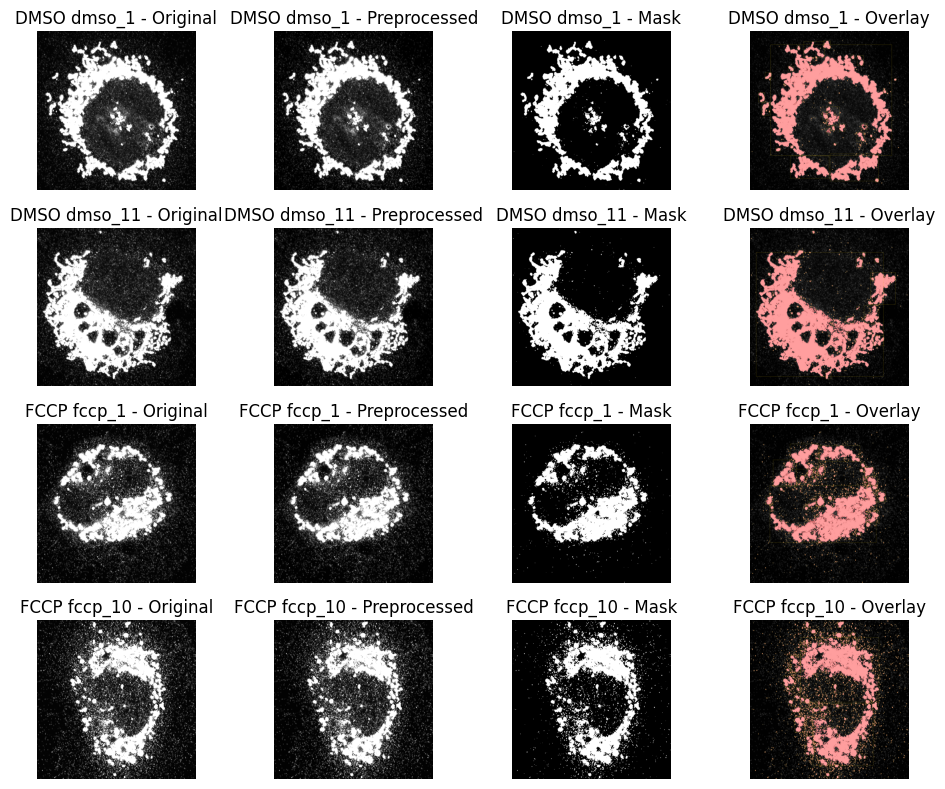

In [7]:
visual_records = []
for condition in ["DMSO", "FCCP"]:
    visual_records.extend([record for record in records if record.condition == condition][:2])

fig, axes = plt.subplots(len(visual_records), 4, figsize=(10, 8))
for row, record in enumerate(visual_records):
    result = analyze_image(record.path, image_id=record.image_id, condition=record.condition)
    image = result["image"]
    segmentation = result["segmentation"]
    panels = [
        (image, "Original"),
        (preprocessed_to_image(segmentation), "Preprocessed"),
        (mask_to_image(segmentation), "Mask"),
        (overlay_mask(image, segmentation), "Overlay"),
    ]
    for col, (panel, title) in enumerate(panels):
        ax = axes[row][col]
        ax.imshow(panel, cmap="gray" if col < 3 else None)
        ax.set_title(f"{record.condition} {record.image_id} - {title}")
        ax.axis("off")

fig.tight_layout()
visual_path = FIGURE_DIR / "notebook_mask_overlay_grid.png"
fig.savefig(visual_path, dpi=180)
visual_path

## 5. Interpretasi Biologis

Mean intensity dan integrated density membantu membaca kekuatan sinyal fluoresensi area mitokondria yang tersegmentasi. Area dan jumlah komponen membantu membaca luas serta fragmentasi foreground. Karena analisis memakai 58 citra full-resolution dari dua kondisi, ringkasan kondisi lebih layak untuk tugas besar dibanding preview dua gambar. Diskusi respirasi sel tetap harus menyatakan bahwa citra TOM20/AlexaFluor 568 tidak mengukur ATP absolut; data tambahan seperti OCR/ECAR atau assay ATP dibutuhkan untuk klaim produksi energi.

In [8]:
print(f"Total citra dianalisis: {len(metrics)}")
print(condition_summary.round(4).to_string(index=False))
print()
for record in visual_records[:2]:
    result = analyze_image(record.path, image_id=record.image_id, condition=record.condition)
    print(f"{record.image_id}: {result['interpretation']}")

Total citra dianalisis: 58
condition  mean_intensity  total_fluorescence  area_pixels  integrated_density  object_count  coverage_fraction  signal_to_background
     DMSO          0.9333         796849.7554  853055.5517         796849.7546      416.9655             0.2034                8.0808
     FCCP          0.9106         906938.6530  995016.8966         906938.6464     1224.3103             0.2372                6.3124



dmso_1: Area fluoresensi terdeteksi seluas 838329 piksel pada 218 komponen. Mean intensity 0.948 dan integrated density 794853.3 dapat digunakan sebagai indikator tidak langsung sinyal/luas struktur mitokondria pada citra ini. Status kualitas: usable. Hasil ini bukan pengukuran ATP absolut.


dmso_11: Area fluoresensi terdeteksi seluas 1015404 piksel pada 288 komponen. Mean intensity 0.940 dan integrated density 954048.5 dapat digunakan sebagai indikator tidak langsung sinyal/luas struktur mitokondria pada citra ini. Status kualitas: usable. Hasil ini bukan pengukuran ATP absolut.


## 6. Kesimpulan

Dataset publik yang sesuai tersedia melalui BBBC053 dan dapat diproses dengan Python. Pendekatan CV klasik dipilih karena sesuai dengan tipe data dan keterbatasan label. Output proyek sudah mencakup loading 58 citra TIFF, preprocessing, segmentasi foreground fluoresensi, connected components, fitur kuantitatif, visualisasi mask/overlay, ringkasan kondisi DMSO vs FCCP, dan interpretasi yang tidak overclaim terhadap ATP.